<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        940 non-null    int64  
 1   ActivityDate              940 non-null    object 
 2   TotalSteps                940 non-null    int64  
 3   TotalDistance             940 non-null    float64
 4   TrackerDistance           940 non-null    float64
 5   LoggedActivitiesDistance  940 non-null    float64
 6   VeryActiveDistance        940 non-null    float64
 7   ModeratelyActiveDistance  940 non-null    float64
 8   LightActiveDistance       940 non-null    float64
 9   SedentaryActiveDistance   940 non-null    float64
 10  VeryActiveMinutes         940 non-null    int64  
 11  FairlyActiveMinutes       940 non-null    int64  
 12  LightlyActiveMinutes      940 non-null    int64  
 13  SedentaryMinutes          940 non-null    int64  
 14  Calories  

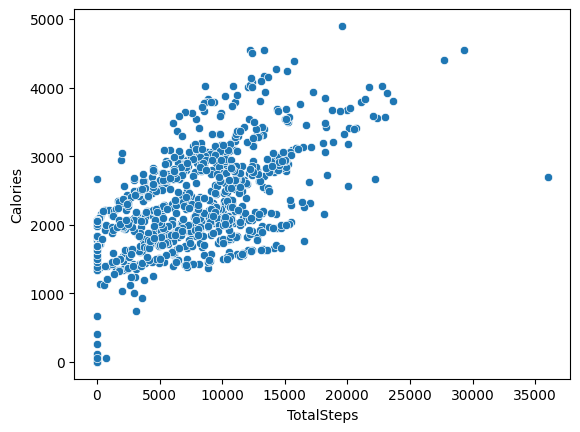

In [1]:
import pandas as pd
import os
os.chdir("d:/strava")

df = pd.read_csv("d:/strava/data/dailyActivity_merged.csv")


sleep = pd.read_csv("d:/strava/data/sleepDay_merged.csv")

# Optional
weight = pd.read_csv("d:/strava/data/weightLogInfo_merged.csv")

df.describe()
df.info()

import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x="TotalSteps", y="Calories", data=df)
plt.show()

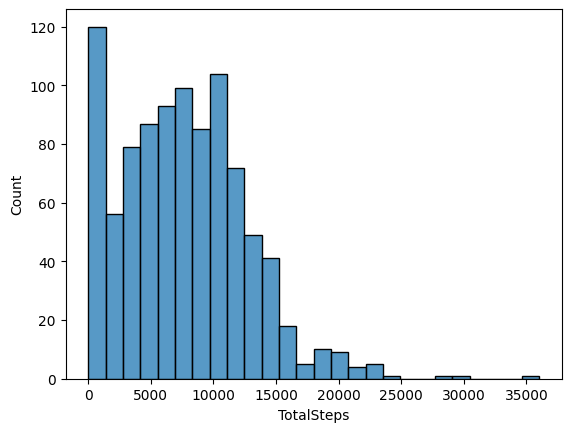

In [2]:
sns.histplot(df["TotalSteps"])
plt.show()

In [4]:
print(df.columns)

Index(['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance',
       'LoggedActivitiesDistance', 'VeryActiveDistance',
       'ModeratelyActiveDistance', 'LightActiveDistance',
       'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes',
       'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories'],
      dtype='object')


In [6]:
activity = pd.read_csv("d:/strava/data/dailyActivity_merged.csv")

activity["ActivityDate"] = pd.to_datetime(activity["ActivityDate"])
sleep["SleepDay"] = pd.to_datetime(sleep["SleepDay"])

C:\Users\aadib\AppData\Local\Temp\ipykernel_13528\3045450802.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sleep["SleepDay"] = pd.to_datetime(sleep["SleepDay"])


In [8]:
activity = pd.read_csv("d:/strava/data/dailyActivity_merged.csv")

activity["ActivityDate"] = pd.to_datetime(activity["ActivityDate"])
sleep["SleepDay"] = pd.to_datetime(sleep["SleepDay"])

In [9]:
df = pd.merge(activity, sleep,
              left_on=["Id", "ActivityDate"],
              right_on=["Id", "SleepDay"],
              how="left")

In [10]:
print(df.columns)

Index(['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance',
       'LoggedActivitiesDistance', 'VeryActiveDistance',
       'ModeratelyActiveDistance', 'LightActiveDistance',
       'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes',
       'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories', 'SleepDay',
       'TotalSleepRecords', 'TotalMinutesAsleep', 'TotalTimeInBed'],
      dtype='object')


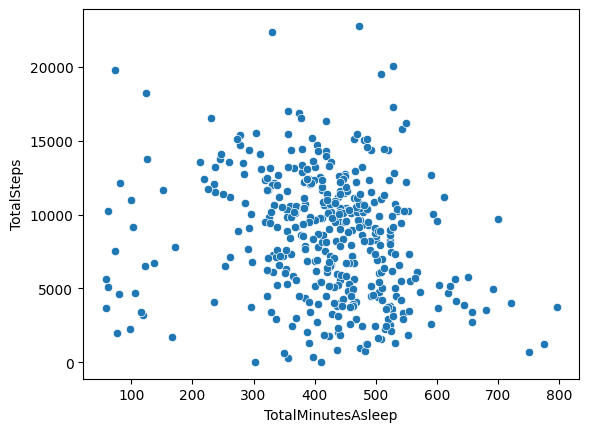

In [11]:
sns.scatterplot(x="TotalMinutesAsleep", y="TotalSteps", data=df)
plt.show()

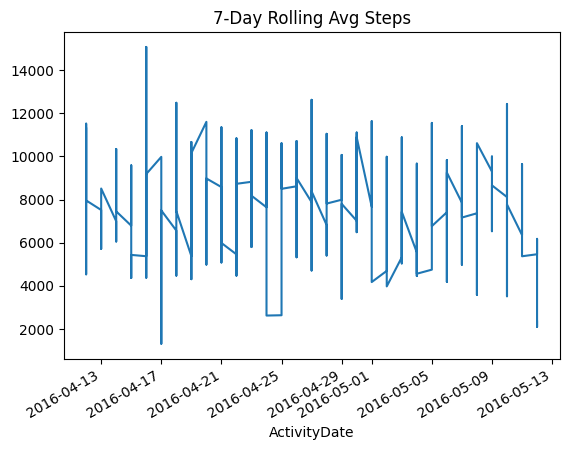

In [12]:
df.sort_values("ActivityDate").set_index("ActivityDate")["TotalSteps"].rolling(7).mean().plot()
plt.title("7-Day Rolling Avg Steps"); plt.show()

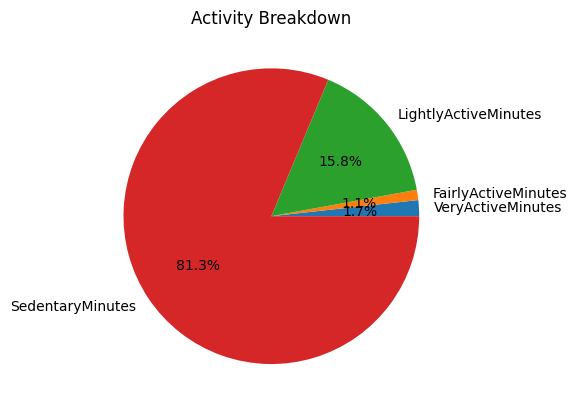

In [13]:
activity_cols = ["VeryActiveMinutes","FairlyActiveMinutes","LightlyActiveMinutes","SedentaryMinutes"]
df[activity_cols].sum().plot(kind="pie", autopct="%1.1f%%")
plt.title("Activity Breakdown"); plt.ylabel(""); plt.show()

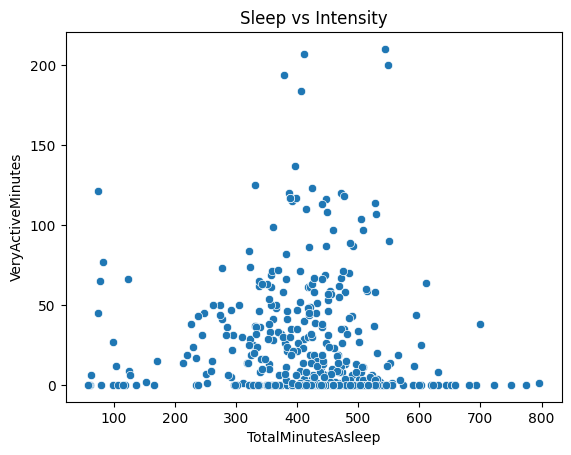

In [14]:
sns.scatterplot(x="TotalMinutesAsleep", y="VeryActiveMinutes", data=df)
plt.title("Sleep vs Intensity"); plt.show()


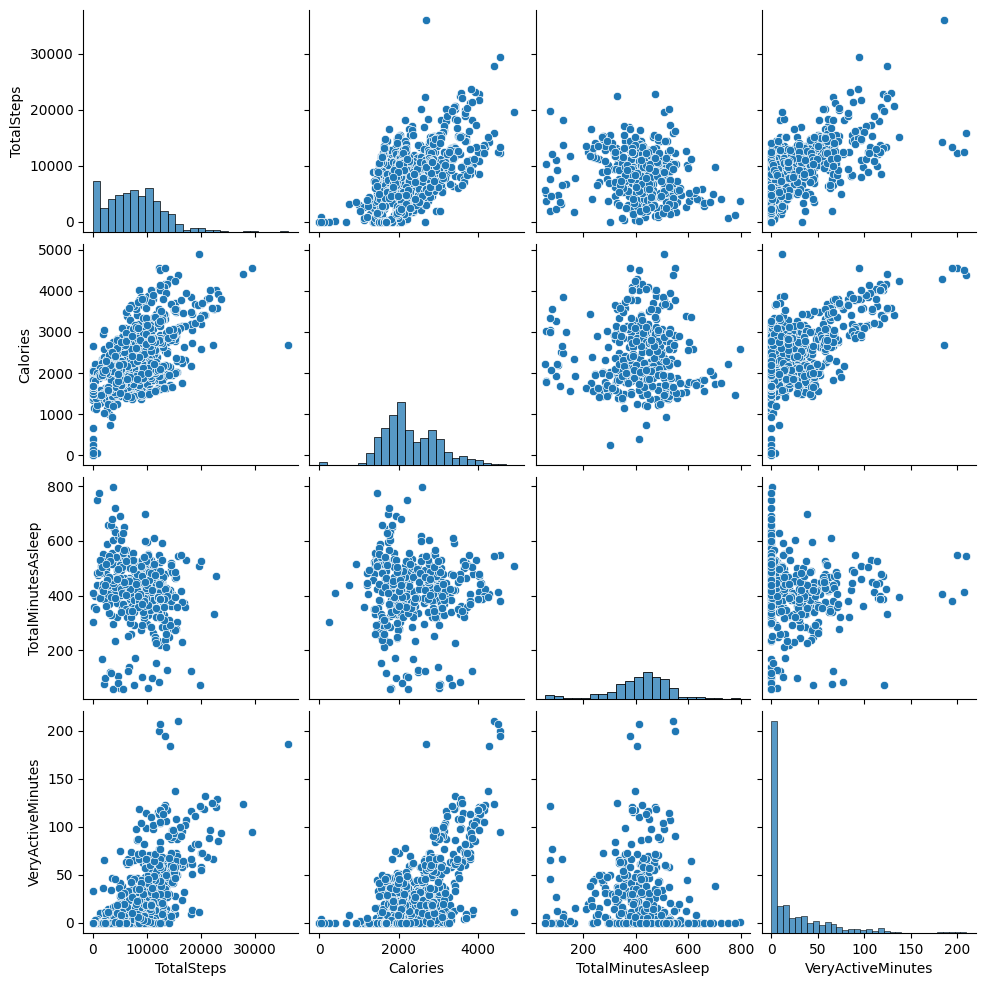

In [15]:
sns.pairplot(df[["TotalSteps","Calories","TotalMinutesAsleep","VeryActiveMinutes"]])
plt.show()

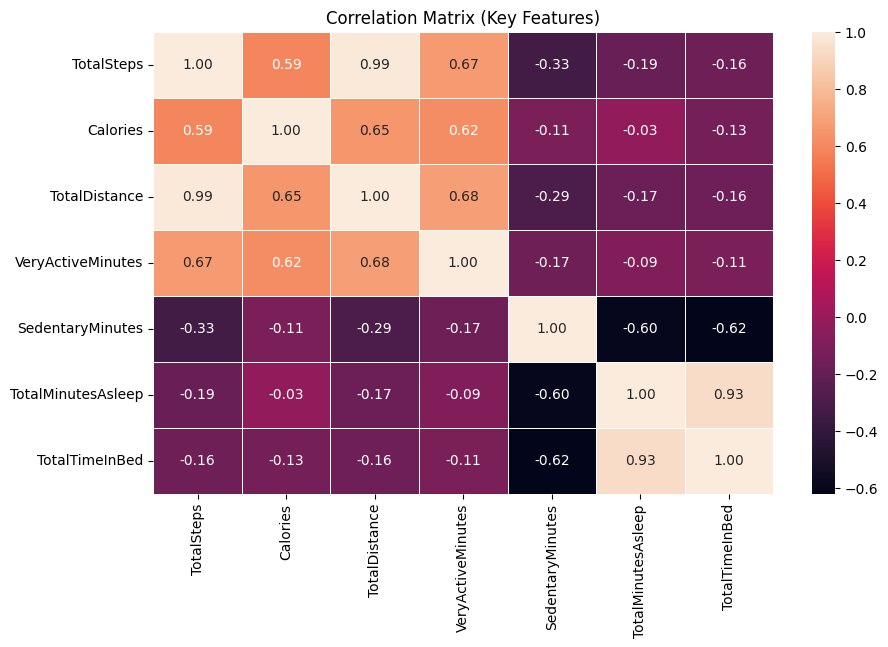

In [45]:
cols = [
    "TotalSteps", "Calories", "TotalDistance",
    "VeryActiveMinutes", "SedentaryMinutes",
    "TotalMinutesAsleep", "TotalTimeInBed"
]

corr = df[cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix (Key Features)")
plt.show()

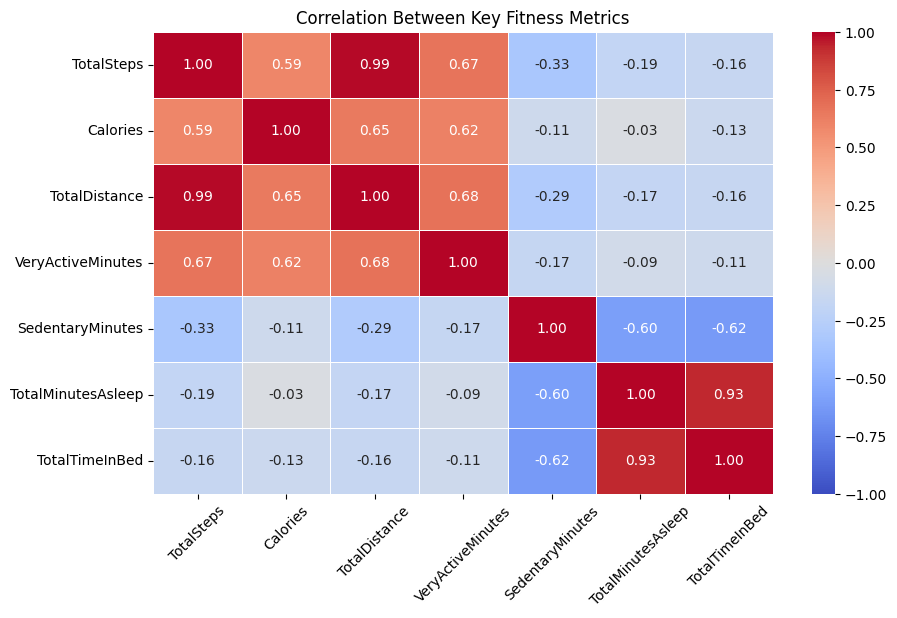

In [46]:
plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Between Key Fitness Metrics")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.show()

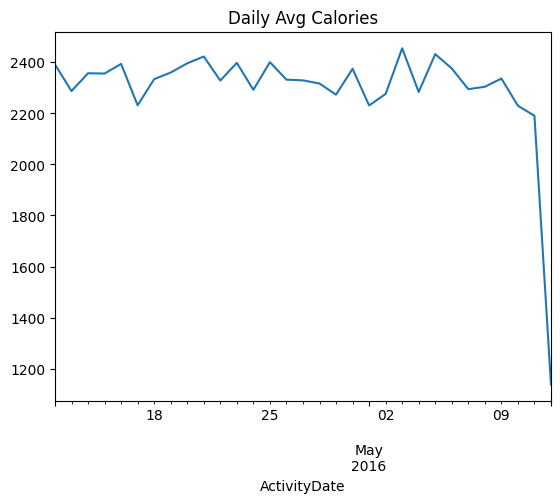

In [18]:
df.groupby("ActivityDate")["Calories"].mean().plot()
plt.title("Daily Avg Calories"); plt.show()

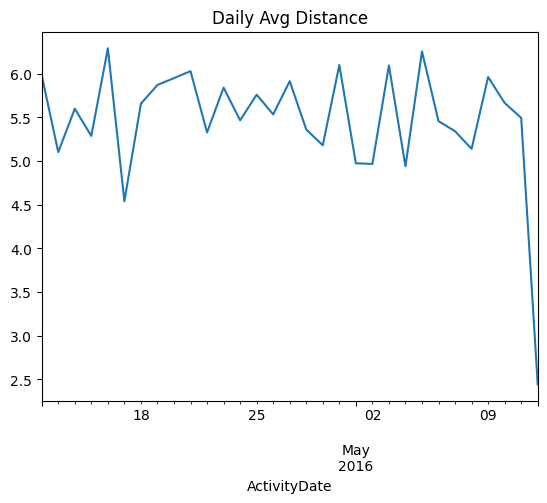

In [19]:
df.groupby("ActivityDate")["TotalDistance"].mean().plot()
plt.title("Daily Avg Distance"); plt.show()

In [22]:
df["ActivityDate"] = pd.to_datetime(df["ActivityDate"])  # ensure datetime

df["DayOfWeek"] = df["ActivityDate"].dt.day_name()


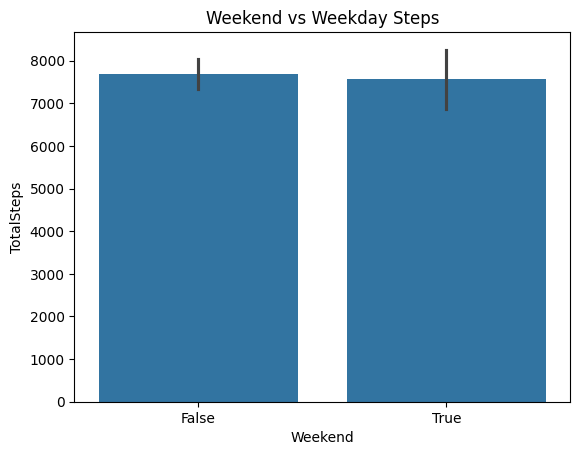

In [25]:
sns.barplot(x="Weekend", y="TotalSteps", data=df)
plt.title("Weekend vs Weekday Steps"); plt.show()

In [24]:
# Make sure ActivityDate is datetime
df["ActivityDate"] = pd.to_datetime(df["ActivityDate"])

# Create DayOfWeek (if not already created)
df["DayOfWeek"] = df["ActivityDate"].dt.day_name()

# Create Weekend column
df["Weekend"] = df["DayOfWeek"].isin(["Saturday", "Sunday"])

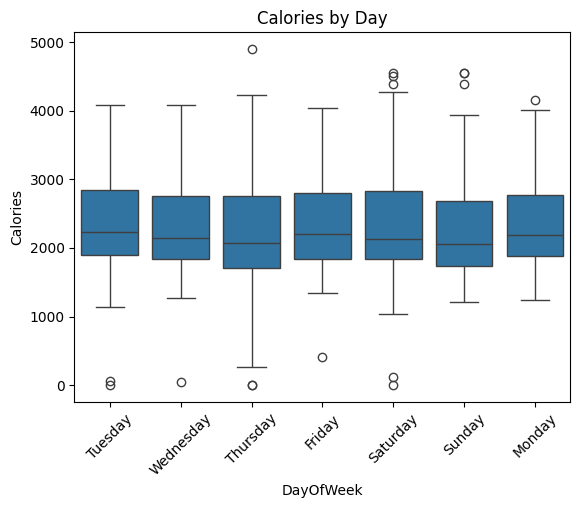

In [26]:
sns.boxplot(x="DayOfWeek", y="Calories", data=df)
plt.title("Calories by Day"); plt.xticks(rotation=45); plt.show()

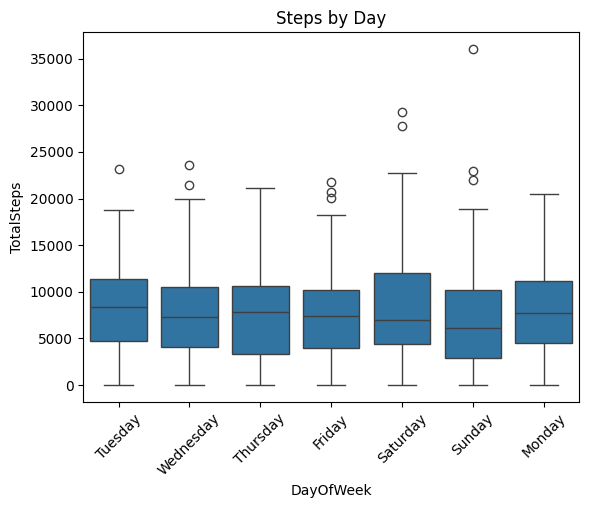

In [27]:
sns.boxplot(x="DayOfWeek", y="TotalSteps", data=df)
plt.title("Steps by Day"); plt.xticks(rotation=45); plt.show()

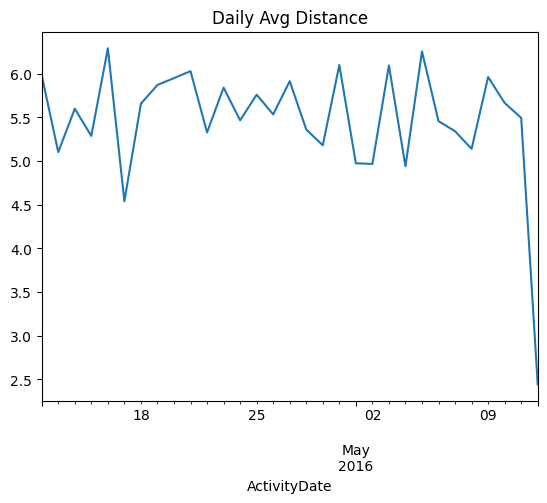

In [28]:
df.groupby("ActivityDate")["TotalDistance"].mean().plot()
plt.title("Daily Avg Distance"); plt.show()

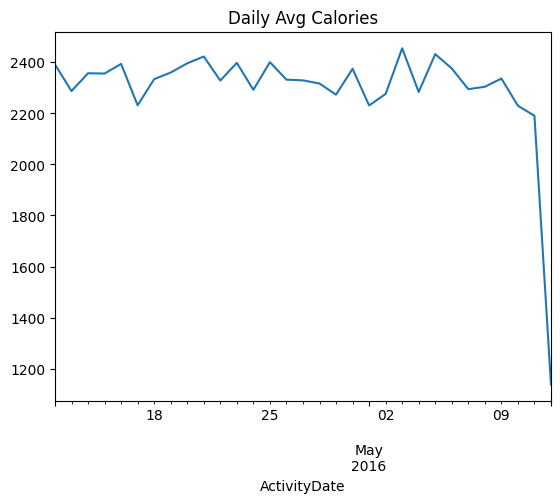

In [29]:
df.groupby("ActivityDate")["Calories"].mean().plot()
plt.title("Daily Avg Calories"); plt.show()


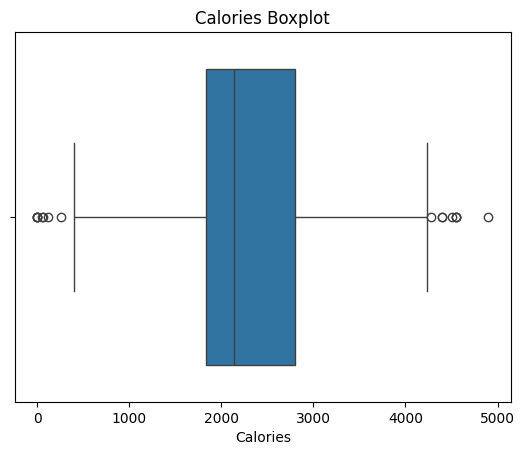

In [30]:
sns.boxplot(x="Calories", data=df); plt.title("Calories Boxplot"); plt.show()

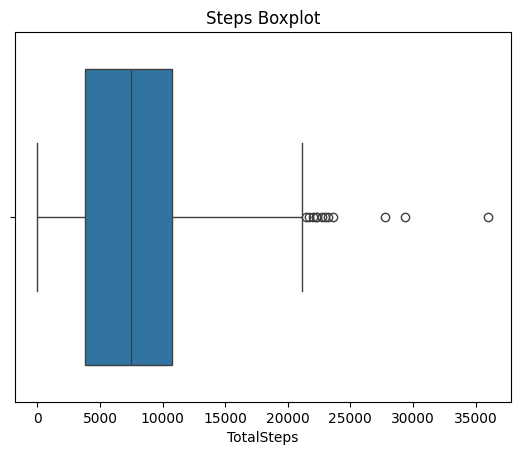

In [31]:
sns.boxplot(x="TotalSteps", data=df); plt.title("Steps Boxplot"); plt.show()

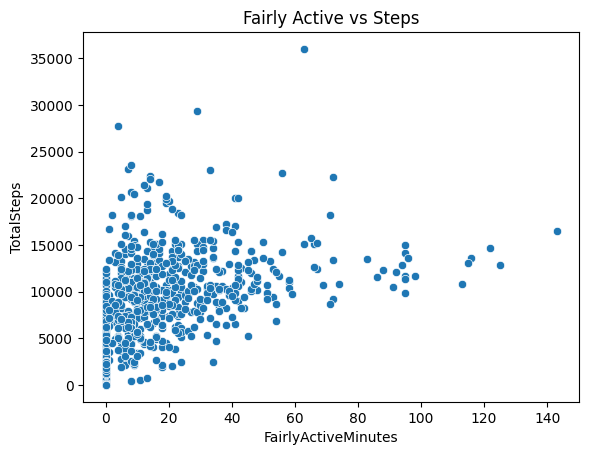

In [32]:
sns.scatterplot(x="FairlyActiveMinutes", y="TotalSteps", data=df); plt.title("Fairly Active vs Steps"); plt.show()

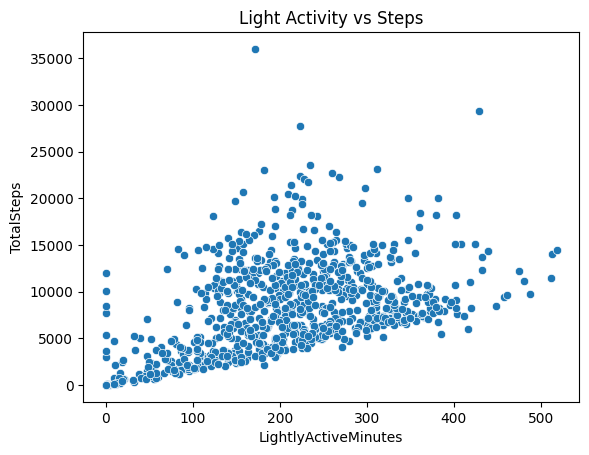

In [33]:
sns.scatterplot(x="LightlyActiveMinutes", y="TotalSteps", data=df); plt.title("Light Activity vs Steps"); plt.show()

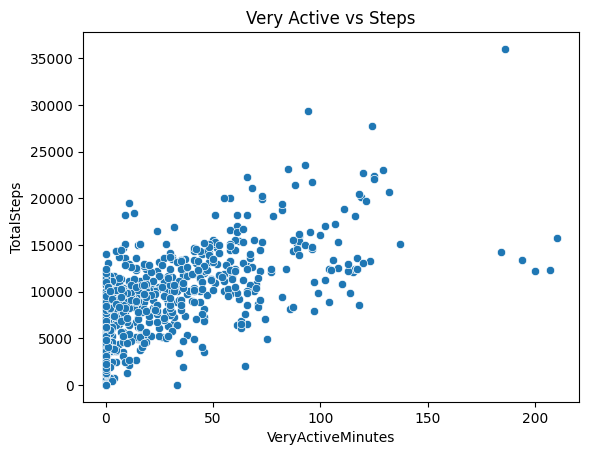

In [34]:
sns.scatterplot(x="VeryActiveMinutes", y="TotalSteps", data=df); plt.title("Very Active vs Steps"); plt.show()

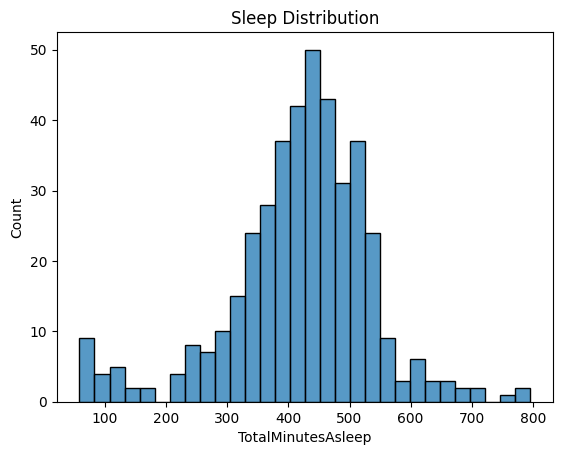

In [35]:
sns.histplot(df["TotalMinutesAsleep"], bins=30); plt.title("Sleep Distribution"); plt.show()

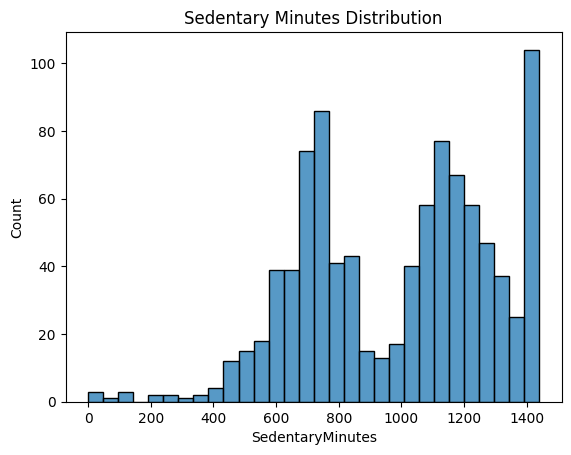

In [36]:
sns.histplot(df["SedentaryMinutes"], bins=30); plt.title("Sedentary Minutes Distribution"); plt.show()

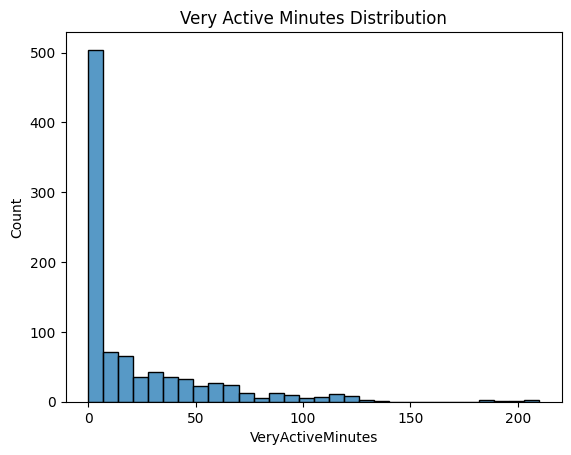

In [37]:
sns.histplot(df["VeryActiveMinutes"], bins=30); plt.title("Very Active Minutes Distribution"); plt.show()

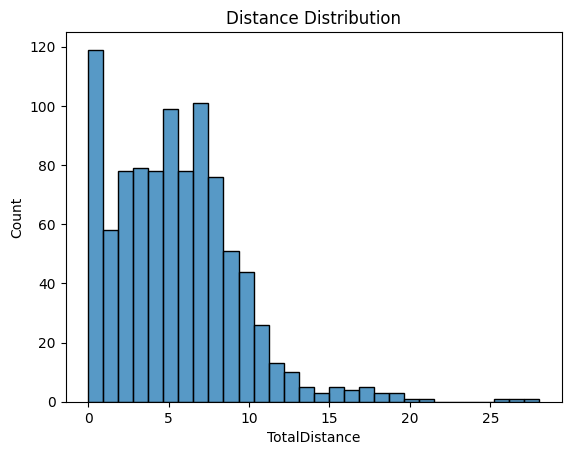

In [38]:
sns.histplot(df["TotalDistance"], bins=30); plt.title("Distance Distribution"); plt.show()

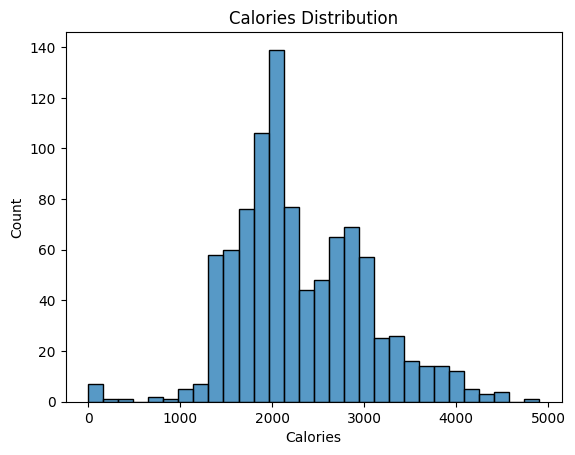

In [39]:
sns.histplot(df["Calories"], bins=30); plt.title("Calories Distribution"); plt.show()


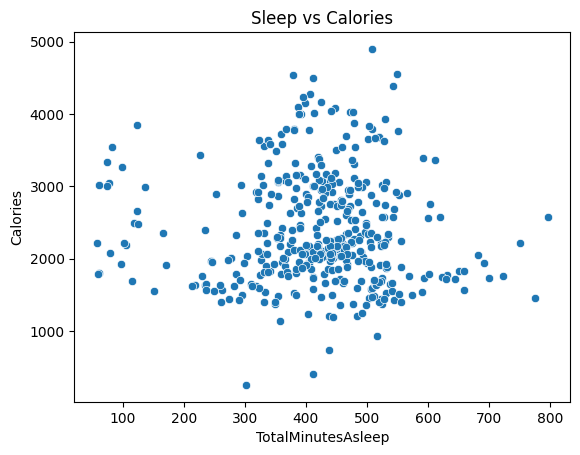

In [40]:
sns.scatterplot(x="TotalMinutesAsleep", y="Calories", data=df); plt.title("Sleep vs Calories"); plt.show()

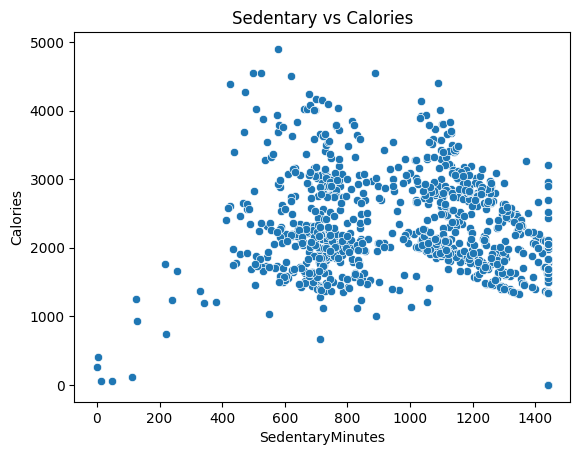

In [41]:

sns.scatterplot(x="SedentaryMinutes", y="Calories", data=df); plt.title("Sedentary vs Calories"); plt.show()


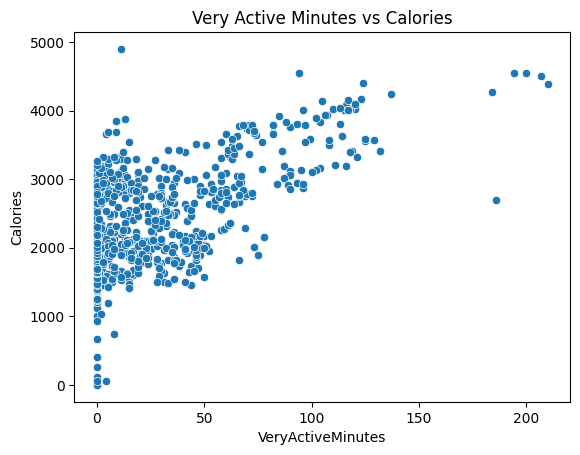

In [42]:
sns.scatterplot(x="VeryActiveMinutes", y="Calories", data=df); plt.title("Very Active Minutes vs Calories"); plt.show()

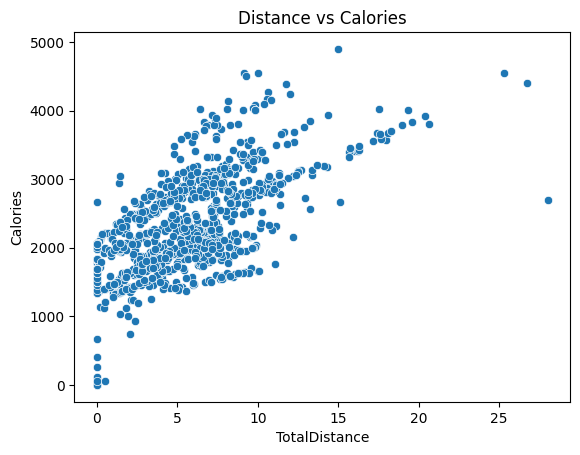

In [43]:
sns.scatterplot(x="TotalDistance", y="Calories", data=df); plt.title("Distance vs Calories"); plt.show()

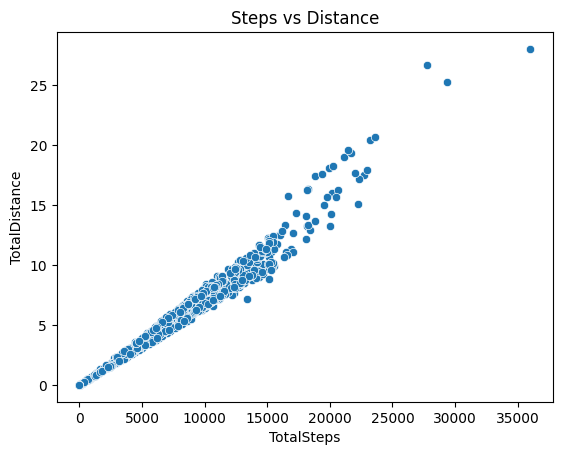

In [44]:
sns.scatterplot(x="TotalSteps", y="TotalDistance", data=df); plt.title("Steps vs Distance"); plt.show()